#### Exploring the datasets doing final necessary data cleaning or formating. Digging deeper to find hidden relationships

In [ ]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb 
from dotenv import load_dotenv
import os

load_dotenv()

PROJECT_ID = os.getenv("GOOGLE_CLOUD_PROJECT")
client = bigquery.Client(project=PROJECT_ID)

# DuckDB handles the dbdate -> datetime conversion automatically
df = duckdb.query("SELECT * FROM '../outputs/training_data.parquet'").to_df()

FEATURES = [
    'zhvi_yoy_smooth', 'zhvi_mom_3m', 'zhvi_volatility_6m',
    'zori_yoy_smooth', 'zori_mom_3m', 'zori_volatility_6m',
    'unemployment_rate', 'unemployment_3m_delta',
    'jobs_3m_pct', 'jobs_yoy_pct', 'wages_yoy_pct',
    'permits_yoy_pct',
    'mortgage_rate_3m_delta', 'mortgage_rate_12m_delta',
    'mortgage_rate_volatility_6m', 'cpi_yoy_pct',
    'price_to_income_ratio', 'piti_rate_pressure',
    'rent_to_income_ratio', 'piti_shock'
]
TARGET = 'hpa_relative'

In [36]:
query = f"""
SELECT
    city,
    month,
    zhvi,
    hpa_12m_forward,
    LEAD(zhvi, 12) OVER (PARTITION BY city ORDER BY month) AS actual_next_zhvi,
    SAFE_DIVIDE(
        LEAD(zhvi, 12) OVER (PARTITION BY city ORDER BY month) - zhvi,
        zhvi
    ) AS computed_forward_hpa
FROM `{PROJECT_ID}`.housing_silver.silver_home_values
WHERE city = 'austin'
AND month BETWEEN '2021-01-01' AND '2023-12-01'
ORDER BY month
"""

df = client.query(query).to_dataframe(create_bqstorage_client=False)
df

,city,month,zhvi,hpa_12m_forward,actual_next_zhvi,computed_forward_hpa
0,austin,2021-01-01,365420.203197,0.3508,493607.961040,0.350795
1,austin,2021-02-01,374218.938533,0.3504,505363.475139,0.350449
2,austin,2021-03-01,386471.057064,0.3459,520153.156112,0.345905
3,austin,2021-04-01,403632.723533,0.3248,534715.100330,0.324757
4,austin,2021-05-01,424696.031448,0.2880,547010.002942,0.288004
5,austin,2021-06-01,445512.968343,0.2441,554272.641716,0.244122
6,austin,2021-07-01,461113.727591,0.2001,553405.111706,0.200149
7,austin,2021-08-01,470046.276566,0.1612,545812.100158,0.161188
8,austin,2021-09-01,473680.738912,0.1277,534155.573632,0.127670
9,austin,2021-10-01,476085.076371,0.0994,523389.906384,0.099362


In [29]:
# Missing Data Audit
missing = df[FEATURES + [TARGET]].isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct})[missing > 0]

,missing,pct
zori_yoy_smooth,21,0.82
zori_mom_3m,21,0.82
zori_volatility_6m,21,0.82
rent_to_income_ratio,21,0.82


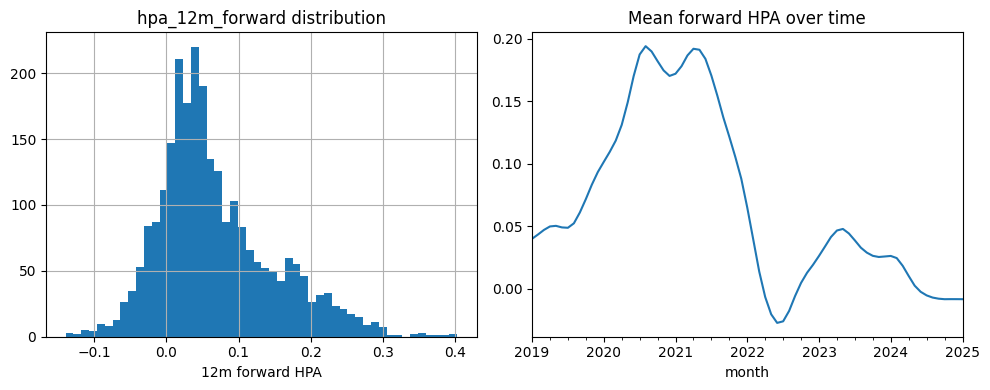

In [30]:
# target distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df[TARGET].hist(bins=50)
plt.title('hpa_12m_forward distribution')
plt.xlabel('12m forward HPA')
plt.subplot(1, 2, 2)
df.groupby('month')[TARGET].mean().plot()
plt.title('Mean forward HPA over time')
plt.tight_layout()
plt.show()

In [31]:
# Checking skewness of the target
# If heavily skewed,Ridge assumes normally distributed errors
print(df[TARGET].describe())
print(f"Skewness: {df[TARGET].skew():.3f}")

count    2554.000000
mean        0.067790
std         0.080106
min        -0.139800
25%         0.015000
50%         0.049350
75%         0.108825
max         0.403100
Name: hpa_12m_forward, dtype: float64
Skewness: 0.822


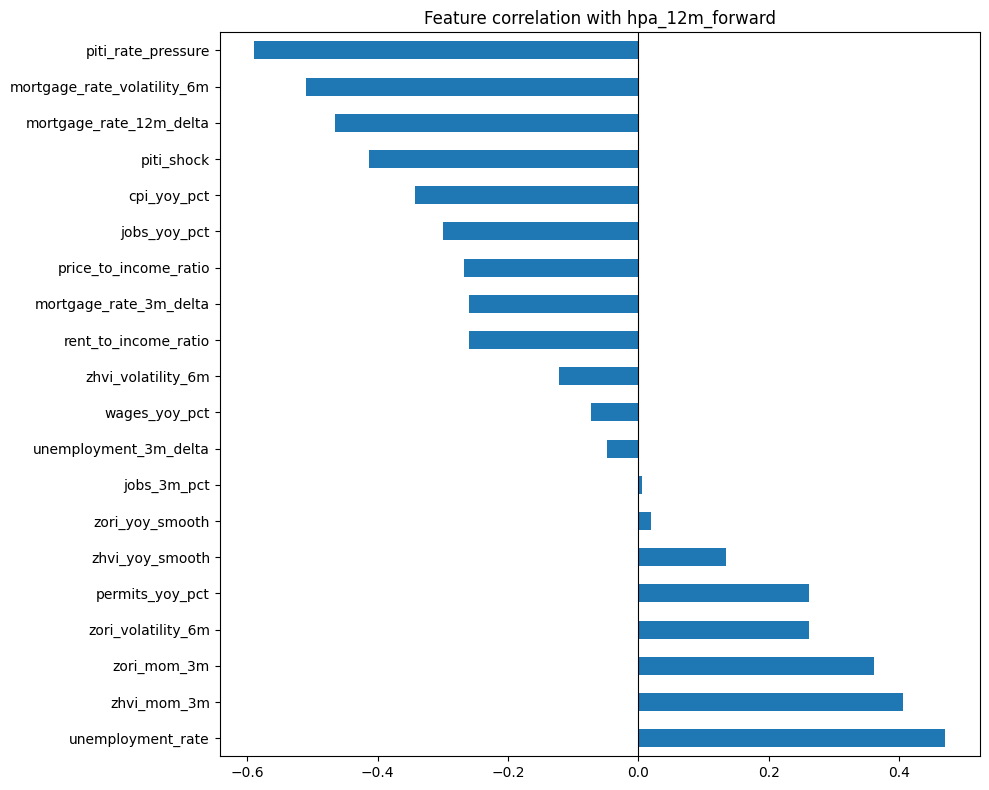

In [32]:
# Feature correlations with target
correlations = df[FEATURES].corrwith(df[TARGET]).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh')
plt.title('Feature correlation with hpa_12m_forward')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

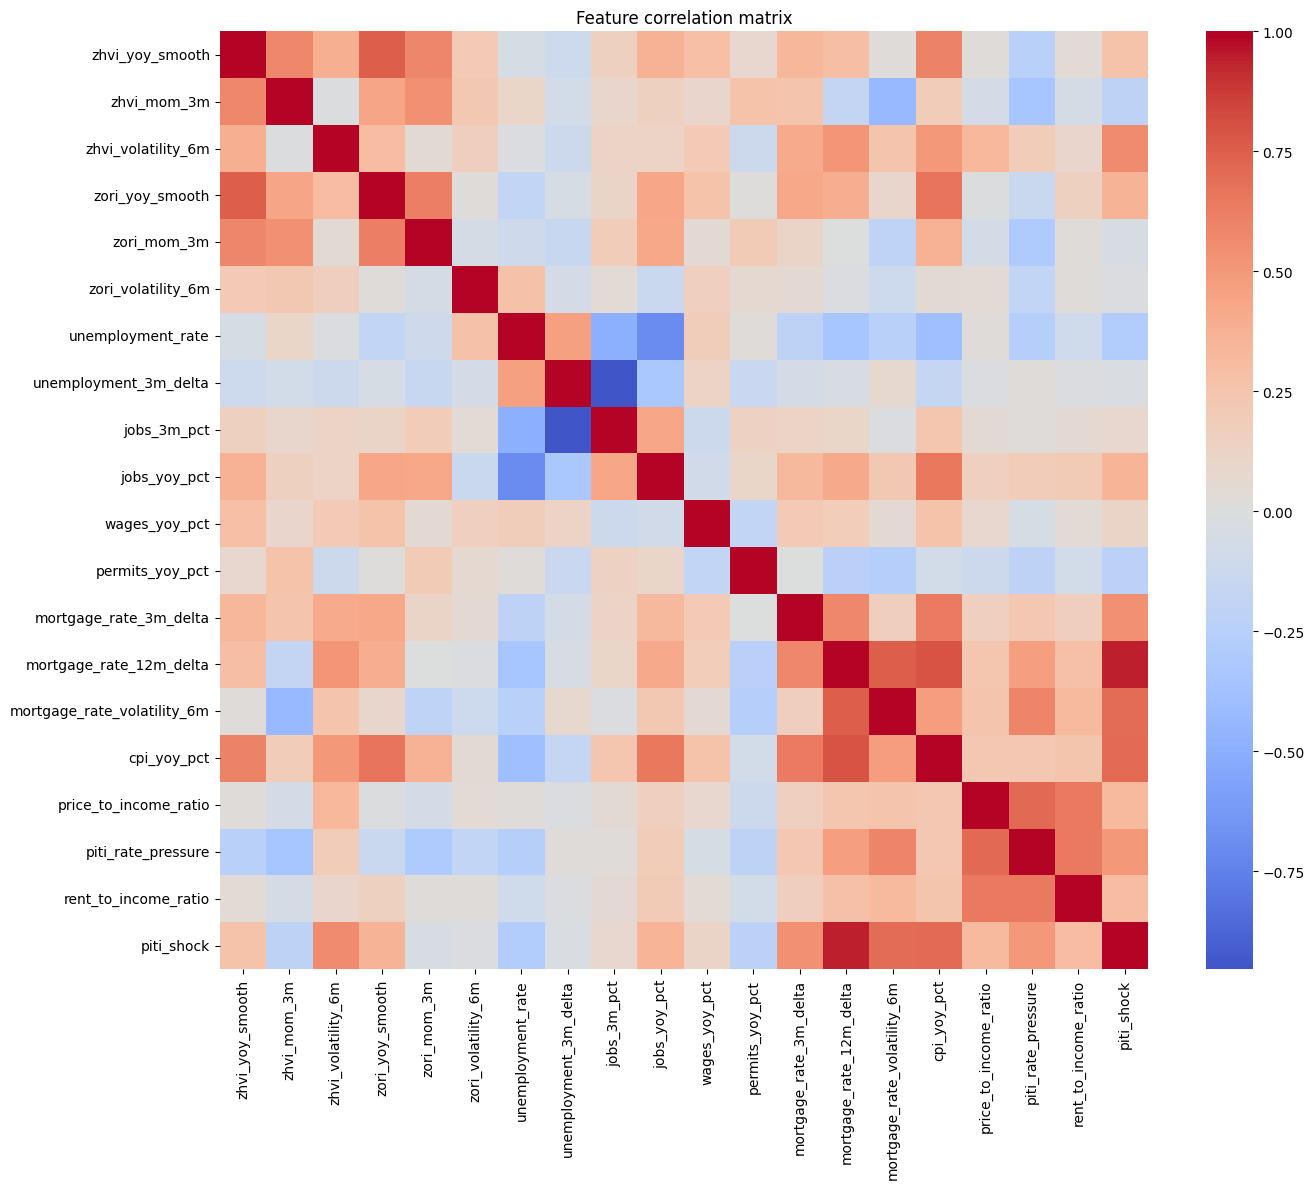

In [33]:
# Multicollinearity Check
plt.figure(figsize=(14, 12))
corr_matrix = df[FEATURES].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

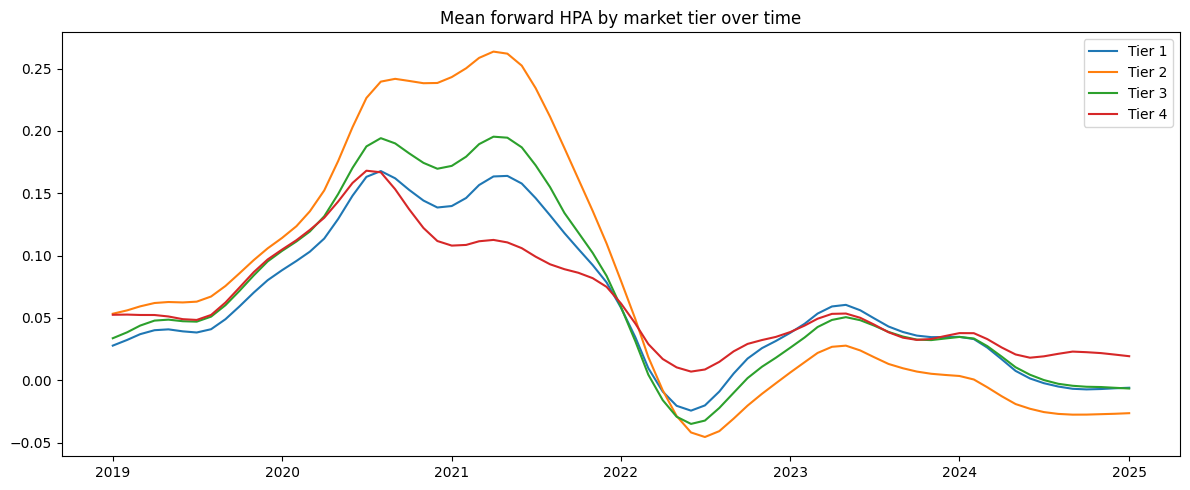

In [34]:
# Target over time by tier
plt.figure(figsize=(12, 5))
for tier in sorted(df['tier'].unique()):
    subset = df[df['tier'] == tier].groupby('month')[TARGET].mean()
    plt.plot(subset.index, subset.values, label=f'Tier {tier}')
plt.title('Mean forward HPA by market tier over time')
plt.legend()
plt.tight_layout()
plt.show()